### Creating Tensors in PyTorch

Let's consider a few different ways of creating tensors, and then see some of their properties and how to manipulate them. Firstly, we can simply create a tensor from a list of a NumPy array using the torch.tensor or the torch.from_numpy function as follows:

In [1]:
import torch
import numpy as np
np.set_printoptions(precision=3)
a = [1, 2, 3]
b = np.array([4, 5, 6], dtype=np.int32)
t_a = torch.tensor(a)
t_b = torch.from_numpy(b)
print(t_a)
print(t_b)

tensor([1, 2, 3])
tensor([4, 5, 6], dtype=torch.int32)


This resulted in tensors t_a and t_b with their properties, shape = (3, ) and dtype = int32. Similar to NumPy arrays, we can also see these properties:

In [2]:
t_ones = torch.ones(2, 3)
t_ones.shape

torch.Size([2, 3])

Creating a tensor of random values can be done as follows:

In [3]:
rand_tensor = torch.rand(2, 3)
print(rand_tensor)

tensor([[0.0181, 0.8548, 0.9139],
        [0.0697, 0.6468, 0.1754]])


### Manipulating the Data Type and Shape of a Tensor

Learning ways to manipulate tensors is necessary to make them compatible for input to a model or an operation. In this section, we will look at how to manipulate tensor data types and shapes via several PyTorch functions that cast, reshape, transpose, and squeeze (remove dimensions).

The torch.to() function can be used to change the data type of a tensor to a desired type:

In [4]:
t_a_new = t_a.to(torch.int64)
print(t_a_new.dtype)

torch.int64


Certain operations require that the input tensors have a certain number of dimensions associated with a certain number of elements. Thus, we might need to change the shape of a tensor, add a new dimension, or squeeze an unnecessary dimension. PyTorch provides useful functions to achieve this, such as torch.transpose(), torch.reshape(), and torch.squeeze(). Let's take a look at some examples:

Transposing a tensor:

In [5]:
t = torch.rand(3, 5)
t_tr = torch.transpose(t, 0, 1)
print(t.shape, '-->', t_tr.shape)

torch.Size([3, 5]) --> torch.Size([5, 3])


Reshaping a tensor (for example, from a 1D vector to a 2D array):

In [6]:
t = torch.zeros(30)
t_reshape = t.reshape(5, 6)
print(t_reshape.shape)

torch.Size([5, 6])


Removing the unnecessary dimensions (dimensions that have size 1, which is not needed):

In [7]:
t = torch.zeros(1, 2, 1, 4, 1)
t_sqz = torch.squeeze(t, 2)
print(t.shape, '-->', t_sqz.shape)

torch.Size([1, 2, 1, 4, 1]) --> torch.Size([1, 2, 4, 1])


### Applying Mathematical Operations to Tensors

Applying mathematical operations, in particular linear algebra operations, is necessary for building most machine learning models. In this subsection, we will cover some widely used linear algebra operations, such as element-wise product, matrix multiplication, and computing the norm of a tensor.

First, let's instantiate two random tensors, one with uniform distribution in the range $[-1, 1)$ and the other with a standard normal distribution:

In [8]:
torch.manual_seed(1)
t1 = 2 * torch.rand(5, 2) - 1
t2 = torch.normal(mean=0, std=1, size=(5,2))

Notice that t1 and t2 hae the same shape. Now, to compute the element-wise product of t1 and t2, we can use the following:

In [9]:
t3 = torch.multiply(t1, t2)
print(t3)

tensor([[ 0.4426, -0.3114],
        [ 0.0660, -0.5970],
        [ 1.1249,  0.0150],
        [ 0.1569,  0.7107],
        [-0.0451, -0.0352]])


To compute the mean, sum, and standard deviation along a certain axis (or axes), we can use torch.mean(), torch.sum(), and torch.std(). For example, the mean of each column in t1 can be computed as follows:

In [10]:
t4 = torch.mean(t1, axis = 0)
print(t4)

tensor([-0.1373,  0.2028])


The matrix-matrix product between t1 and t2 (that is, $t_1 \times t_2^{T} $) can be computed using the torch.matmul() function as follows:

In [11]:
t5 = torch.matmul(t1, torch.transpose(t2, 0, 1))
print(t5)

tensor([[ 0.1312,  0.3860, -0.6267, -1.0096, -0.2943],
        [ 0.1647, -0.5310,  0.2434,  0.8035,  0.1980],
        [-0.3855, -0.4422,  1.1399,  1.5558,  0.4781],
        [ 0.1822, -0.5771,  0.2585,  0.8676,  0.2132],
        [ 0.0330,  0.1084, -0.1692, -0.2771, -0.0804]])


On the other hand, computing $t_1^{T} \times t_2$ is performed by transposing t1, resulting in an array of size $2 \times 2$:

In [12]:
t6 = torch.matmul(torch.transpose(t1, 0, 1), t2)
print(t6)

tensor([[ 1.7453,  0.3392],
        [-1.6038, -0.2180]])


Finally, the torch.linalg.norm() function is useful for computing the $L^{P}$ norm of a tensor. For example, we can calculate the $L^{2}$ norm of t1 as follows:

In [13]:
norm_t1 = torch.linalg.norm(t1, ord=2, dim=1)
print(norm_t1)

tensor([0.6785, 0.5078, 1.1162, 0.5488, 0.1853])


### Split, Stack, and Concatenate Tensors

In this subsection, we will cover PyTorch operations for splitting a tensor into multiple tensors, or the reverse: stacking and concatenating tensors into a single one.

Assume that we have a single tensor, and we want to split it into two or more tensors. For this, PyTorch provides a convenient torch.chunk() function, which divides an input tensor into a list of equally sized tensors. We can determine the desired number of splits as an integer using chunk argument to split a tensor along the desired dimension specified by the dim argument. In this case, the total size of the input tensor along the specified dimension must be divisible by the desired number of splits. Alternatively, we can provide the desired sizes in a list using the torch.split() function. Let's have a look at an example of both these options.

Providing the number of splits:

In [14]:
torch.manual_seed(1)
t = torch.rand(6)
print(t)

t_splits = torch.chunk(t, 3)
[item.numpy() for item in t_splits]

tensor([0.7576, 0.2793, 0.4031, 0.7347, 0.0293, 0.7999])


[array([0.758, 0.279], dtype=float32),
 array([0.403, 0.735], dtype=float32),
 array([0.029, 0.8  ], dtype=float32)]

Providing the sizes of different splits:

In [15]:
torch.manual_seed(1)
t = torch.rand(5)
print(t)

t_splits = torch.split(t, split_size_or_sections=[3, 2])
[item.numpy() for item in t_splits]

tensor([0.7576, 0.2793, 0.4031, 0.7347, 0.0293])


[array([0.758, 0.279, 0.403], dtype=float32),
 array([0.735, 0.029], dtype=float32)]

Note that we are using torch.split instead of torch.chunk

Sometimes, we are working with multiple tensors and need to concatenate or stack them to create a single tensor. In this case, PyTorch functions such as torch.stack() and torch.cat() come in handy. For example, let's create a 1D tensor, A, containing 1s with size 3, and a 1D tensor, B, containing 0s with size 2, and concatenate them into a 1D tensor, C, of size 5:

In [16]:
A = torch.ones(3)
B = torch.zeros(2)
C = torch.cat([A, B], axis=0)
print(C)

tensor([1., 1., 1., 0., 0.])


If we create 1D tensors A and B with size 3, then we can stack them together to form a 2D tensor S:

In [17]:
A = torch.ones(3)
B = torch.zeros(3)
S = torch.stack([A, B], axis=1)
print(S)

tensor([[1., 0.],
        [1., 0.],
        [1., 0.]])


### Creating a PyTorch DataLoader from Existing Tensors

If the data already exists in the form of a tensor object, a Python list, or a NumPy array, we can easily create a dataset loader using the torch.utils.data.DataLoader() class. It returns an object of the DataLoader class, which we can use to iterate through the individual elements in the input dataset. As a simple example, consider the following code, which creates a dataset from a list of values from 0 to 5:

In [18]:
from torch.utils.data import DataLoader
t = torch.arange(6, dtype=torch.float32)
data_loader = DataLoader(t)

We can easily iterate through the dataset entry by entry as follows:

In [19]:
for item in data_loader:
    print(item)

tensor([0.])
tensor([1.])
tensor([2.])
tensor([3.])
tensor([4.])
tensor([5.])


If we want to create batches from this dataset, with a desired batch size of 3, we can do this with the batch_size argument as follows:

In [20]:
data_loader = DataLoader(t, batch_size=3, drop_last=False)
for i, batch in enumerate(data_loader):
    print(f'batch {i}:', batch)

batch 0: tensor([0., 1., 2.])
batch 1: tensor([3., 4., 5.])


This will create to batches from this dataset, where the first three elements go into batch #1, and the remaining elements go into batch #2. The optional drop_last argument is useful for cases when the number of elements in the tensor is not divisible by the desired batch size. We can drop the last non-full batch by setting drop_last to True. The default value for drop_last is False.

We can always iterate through a dataset directly, but as you just saw, DataLoader provides an automatic and customizable batching to a dataset.

### Combining Two Tensors Into a Joint Dataset

Often, we may have the data in two (or possibly more) tensors. For example, we could have a tensor for features and a tensor for labels. In such cases, we need to build a dataset that combines these tensors, which allow us to retrieve the elements of these tensors in tuples.

Assume that we have two tensors, t_x and t_y. Tensor t_x holds our feature value, each of size 3, and t_stores the class labels. For this example, we first create these two tensors as follows:

In [21]:
torch.manual_seed(1)
t_x = torch.rand([4, 3], dtype=torch.float32)
t_y = torch.arange(4)

Now, we want to create a joint dataset from these two tensors. We first need to create a Dataset class as follows:

In [22]:
from torch.utils.data import Dataset

class JointDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

A custom Dataset class must contain the following methods to be used by the data loader later on :

- __init__(): This is where the initial logic happens, such as reading existing arrays, loading file, filtering data, and so forth
- __getitem__(): This returns the corresponding sample to the given index.

Then we create a joint dataset of t_x and t_y with the custom Dataset class as follows:

In [23]:
from torch.utils.data import TensorDataset
joint_dataset = JointDataset(t_x, t_y)

Finally, we can print each example of the joint dataset as follows:

In [24]:
for example in joint_dataset:
    print(' x: ', example[0], ' y: ', example[1])

 x:  tensor([0.7576, 0.2793, 0.4031])  y:  tensor(0)
 x:  tensor([0.7347, 0.0293, 0.7999])  y:  tensor(1)
 x:  tensor([0.3971, 0.7544, 0.5695])  y:  tensor(2)
 x:  tensor([0.4388, 0.6387, 0.5247])  y:  tensor(3)


We can also simply utilize the torch.utils.data.TensorDataset class, if the second dataset is a labeled dataset in the form of tensors. So, instead of using our self-defined Dataset class, JointDataset, we can create a joint dataset as follows:

In [25]:
joint_dataset = TensorDataset(t_x, t_y)

Note that a common source of error could be that the element-wise correspondence between the original features (x) and labels (y) might be lost (for example, if the two datasets are shuffled separately). However, once they are merged into one dataset, it is safe to apply these operations.

If we have a dataset created from the list of image filenames on disk, we can define a function to load the images from these filenames. You will see an example of applying multiple transformations to a dataset later.

### Shuffle, Batch and Repeat

As we mentioned, when training an NN model using stochastic gradient descent optimization, it is important to feed training data as randomly shuffled batches. We have already seen how to specify the batch size using the batch_size argument of a data loader object. Now, in addition to creating batches, we will see how to shuffle and reiterate over the datasets. We will continue working with the previous joint dataset.

First, let's create a shuffled version data loader from the joint_dataset dataset:

In [26]:
torch.manual_seed(1)
data_loader = DataLoader(dataset=joint_dataset, batch_size=2, shuffle=True)

Here, each batch contains two data records (x) and corresponding labels (y). Now we iterate through the data loader entry by entry as follows:

In [27]:
for i, batch in enumerate(data_loader, 1):
    print(f'batch {i}:', 'x:', batch[0], 
          '\n         y:', batch[1])

batch 1: x: tensor([[0.3971, 0.7544, 0.5695],
        [0.7576, 0.2793, 0.4031]]) 
         y: tensor([2, 0])
batch 2: x: tensor([[0.7347, 0.0293, 0.7999],
        [0.4388, 0.6387, 0.5247]]) 
         y: tensor([1, 3])


The rows are shuffled without losing the one-to-one correspondence between the entries in x and y. 

In addition, when training a model for multiple epochs, we need to shuffle and iterate over the dataset by the number of deired epochs. So let's iterate over the batched dataset twice:

In [28]:
for epoch in range(2):
    print(f'epoch {epoch+1}')
    for i, batch in enumerate(data_loader, 1):
        print(f'batch {i}:', 'x:', batch[0], 
              '\n         y:', batch[1])

epoch 1
batch 1: x: tensor([[0.7576, 0.2793, 0.4031],
        [0.3971, 0.7544, 0.5695]]) 
         y: tensor([0, 2])
batch 2: x: tensor([[0.7347, 0.0293, 0.7999],
        [0.4388, 0.6387, 0.5247]]) 
         y: tensor([1, 3])
epoch 2
batch 1: x: tensor([[0.4388, 0.6387, 0.5247],
        [0.3971, 0.7544, 0.5695]]) 
         y: tensor([3, 2])
batch 2: x: tensor([[0.7576, 0.2793, 0.4031],
        [0.7347, 0.0293, 0.7999]]) 
         y: tensor([0, 1])


This results in two different sets of batches. In the first epoch, the first batch contains a pair of values [y=0, y=2], and the second batch contains a pair of values [y=1, y=3]. In the second epoch, two batches contain a pair of values, [y=3, y=2] and [y=0, y=1] respectively. For each iteration, the elements within a batch are also shuffled.

### Creating a Dataset from Files on Your Local Storage Disk

In this section, we will build a dataset from images stored on disk. This small dataset will show how building a dataset from stored files generally work. To accomplish this, we will use two additional modules: Image in PIL to read the image file contents and transforms in torchvision to decode the raw contents and resize the images.

Before we start, let's take a look at the contents of these files. We will use the pathlib library to generate a list of image files:

In [29]:
import pathlib
imgdir_path = pathlib.Path("cat_dog_images")
file_list = sorted([str(path) for path in imgdir_path.glob('*.jpg')])
print(file_list)

['cat_dog_images\\cat-01.jpg', 'cat_dog_images\\cat-02.jpg', 'cat_dog_images\\cat-03.jpg', 'cat_dog_images\\dog-01.jpg', 'cat_dog_images\\dog-02.jpg', 'cat_dog_images\\dog-03.jpg']


Next, we will visualize these images using Matplotlib:

Image shape: (900, 1200, 3)
Image shape: (900, 1200, 3)
Image shape: (900, 742, 3)
Image shape: (800, 1200, 3)
Image shape: (800, 1200, 3)
Image shape: (900, 1200, 3)


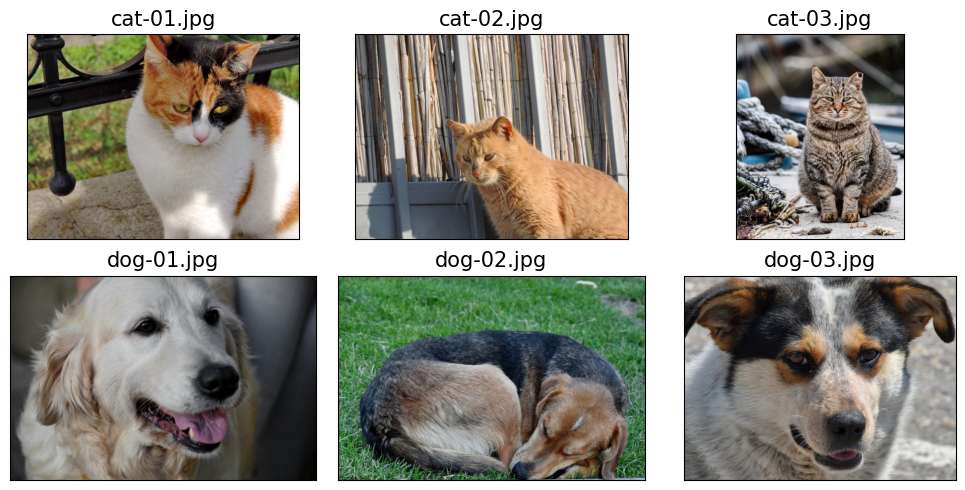

In [30]:
import matplotlib.pyplot as plt
import os
from PIL import Image
fig = plt.figure(figsize=(10, 5))
for i, file in enumerate(file_list):
    img = Image.open(file)
    print('Image shape:', np.array(img).shape)
    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(img)
    ax.set_title(os.path.basename(file), size=15)
plt.tight_layout()
plt.show()

Just from this visualization and the printed image shapes, we can already see that the images have different aspect ratios. If you print aspect ratios (or data array shapes) of these images, you will see that some images are 900 pixels high and 1200 pixels wide ($900 \times 1200$), some are $800 \times 1200$, and one is $900 \times 742$. Later, we will preprocess these images to a consistent size. Another point to consider is that the labels for these images are provided within their filenames. So, we extract these labels form the list of filenames, assigning label 1 to dogs and label 0 to cats:

In [31]:
labels = [1 if 'dog' in os.path.basename(file) else 0 
          for file in file_list]
print(labels)

[0, 0, 0, 1, 1, 1]


Now, we have two lists: a list of filenames (or paths of each image) and a list of their labels. In the previous section, we created a joint dataset from two arrays. Here we will do the following:

In [32]:
class ImageDataset(Dataset):
    def __init__(self, file_list, labels):
        self.file_list = file_list
        self.labels = labels

    def __getitem__(self, index):
        file = self.file_list[index]
        label = self.labels[index]
        return file, label

    def __len__(self):
        return len(self.labels)

image_dataset = ImageDataset(file_list, labels)
for file, label in image_dataset:
    print(file, label)
        

cat_dog_images\cat-01.jpg 0
cat_dog_images\cat-02.jpg 0
cat_dog_images\cat-03.jpg 0
cat_dog_images\dog-01.jpg 1
cat_dog_images\dog-02.jpg 1
cat_dog_images\dog-03.jpg 1


The joint dataset has filenames and labels.

Next, we need to apply transformations to this dataset: load the image content from its file path, decode the raw content, and resize it to a desired size, for example $80 \times 120$. As mentioned before, we use torchvision.transforms module to resize the images and convert the loaded pixels into tensors as follows:

In [33]:
import torchvision.transforms as transforms
img_height, img_width = 80, 120
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((img_height, img_width)), 
])

Now, we update the ImageDataset class with the transform we just defined:

In [34]:
class ImageDataset(Dataset):
    def __init__(self, file_list, labels, transform=None):
        self.file_list = file_list
        self.labels = labels
        self.transform = transform

    def __getitem__(self, index):
        img = Image.open(self.file_list[index])
        if self.transform is not None:
            img = self.transform(img)
        label = self.labels[index]
        return img, label

    def __len__(self):
        return len(self.labels)

image_dataset = ImageDataset(file_list, labels, transform)

Finally, we visualize these transformed image examples using Matplotlib:

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.000551827..1.0000002].


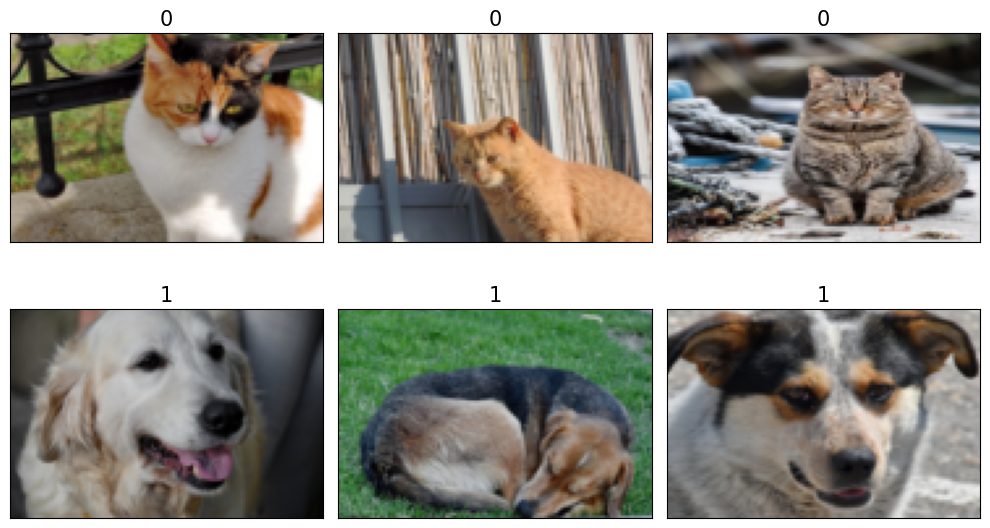

In [35]:
fig = plt.figure(figsize=(10, 6))
for i, example in enumerate(image_dataset):
    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(example[0].numpy().transpose(1, 2, 0))
    ax.set_title(f"{example[1]}", size=15)

plt.tight_layout()
plt.show()

The __getitem__ method in the ImageDataset class wraps all four steps into a single function, including the loading of the raw content (images and labels), decoding the images into tensors, and resizing the images. The function then returns a dataset that we can iterate over and apply other operations that we learned about in the previous sections via a data loader, such as shuffling and batching.

### Fetching Available Datasets from the torchvision.datasets Library

The torchvision.datasets library provides a nice collection of freely available image datasets for training or evaluating deep learning models. Similarly, the torchtext.datasets library provides datasets for natural language. Here, we use torchvision.datasets as an example.

The torchvision datasets are nicely formatted and come with informative descriptions, including the format of features and labels and their type and dimensionality, as well as the link to the original source of the dataset. Another advantage is that these datasets are all subclasses of torch.utils.data.Dataset, so all the functions we covered in the previous sections can be used directly.

We will cover fetching two different datasets: CelebA (celeb_a) and the MNIST digit dataset.

Let's first work with the CelebA dataset with torchvision.datasets.CelebA, the description of which provides some useful information to help us understand the structure:
- The database has three subsets, 'train', 'valid', and 'test'. We can select a specific subset or load all of them with the split parameter.
- The images are stored in PIL.Image format. And we can obtain a transformed version using a custom transform function, such as transforms.ToTensor and transforms.Resize
- There are different types of targets we can use, including 'attributes', 'identity', and 'landmarks'. 'attributes' is 40 facial attributes for the person in the image, such as facial expression, makeup, hair properties, and so on; 'identity' is the person ID for an image; and 'landmarks' refers to the dictionary of extracted facial points, such as the position of the eyes, nose and so on.

Next, we will call the torchvision.datasets.CelebA class to download the data, store it on disk in a designated folder, and load it into a torch.utils.data.Dataset object:

In [36]:
import torchvision
image_path = './'
celeba_dataset = torchvision.datasets.CelebA(
    image_path, download=False, split='train', target_type='attr')

Now that we have instantiated the datasets, let's check if the object is of torch.utils.data.Dataset class:

In [37]:
assert isinstance(celeba_dataset, torch.utils.data.Dataset)

As mentioned, the dataset is already split into train, test, and validation datasets, and we only load the train set. And we use the 'attributes' target. In order to see what the data examples look like, we can execute the following code:

In [38]:
example = next(iter(celeba_dataset))
print(example)

(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=178x218 at 0x22D49CDBB30>, tensor([0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1]))


Note that the sample in this dataset comes in a tuple of (PIL.Image, attributes). If we want to pass this dataset to a supervised deep learning model during training, we have to reformat it as a tuple of (features tensor, label). For the label, we will use the 'Smiling' category from the attributes as an example, which is the 31st element.

Finally, let's take the first 18 examples from it to visualize them with their 'Smiling' labels:

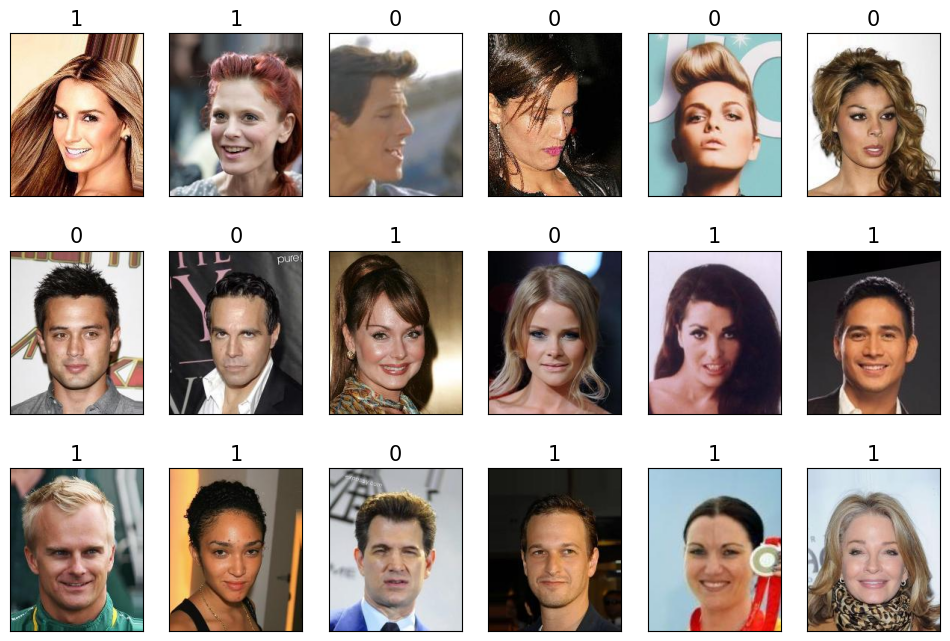

In [39]:
from itertools import islice
fig = plt.figure(figsize=(12, 8))
for i, (image, attributes) in islice(enumerate(celeba_dataset), 18):
    ax = fig.add_subplot(3, 6, i+1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(image)
    ax.set_title(f'{attributes[31]}', size = 15)

plt.show()

This was all we needed to do fetch and use the CelebA image dataset.

Next, we will proceed with the second dataset from torchvision.datasets.MNIST. Let's see how it can be used to fetch the MNIST digit dataset:

- The dataset has two partitions, 'train' and 'test'. We need to select a specific subset to load.
- The images are stored in PIL.Image format. And we can obtain a transformed version using a custom transformation function, such as transforms.ToTensor and transforms.Resize.
- There are 10 classes for the target, from 0 to 9.

Now, we can download the 'train' partition, convert the elemtns to tuples, and visualize 10 examples:

(<PIL.Image.Image image mode=L size=28x28 at 0x22D4F318E60>, 5)


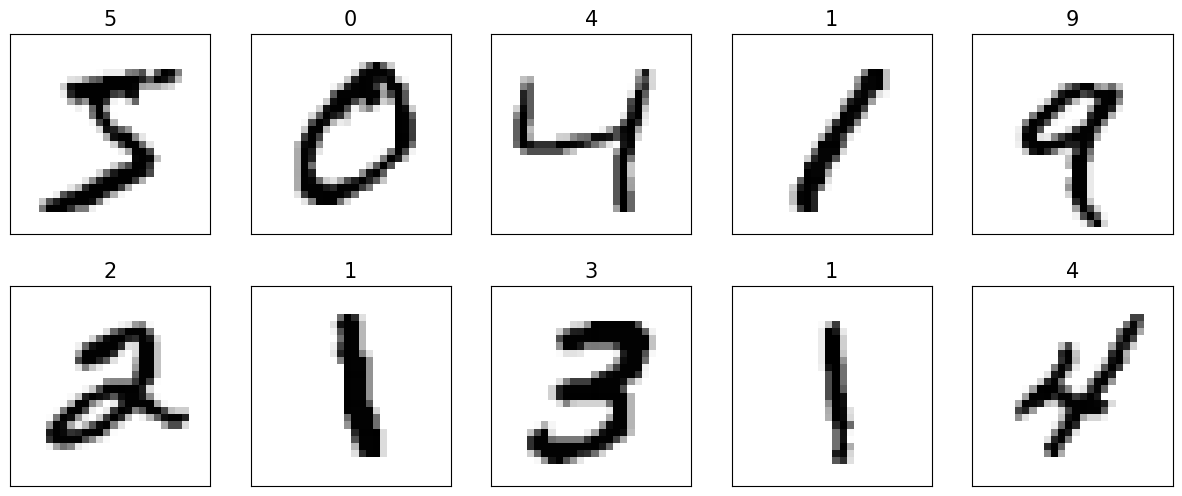

In [40]:
mnist_dataset = torchvision.datasets.MNIST(image_path, 'train', 
                                           download=True)

assert isinstance(mnist_dataset, torch.utils.data.Dataset)
example = next(iter(mnist_dataset))
print(example)

fig = plt.figure(figsize=(15, 6))
for i, (image, label) in islice(enumerate(mnist_dataset), 10):
    ax = fig.add_subplot(2, 5, i+1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(image, cmap='gray_r')
    ax.set_title(f'{label}', size=15)

plt.show()

This concludes our coverage of building and manipulating datasets and fetching datasets from the torchvision.datasets library. Next, we will see how to build NN models in PyTorch.

### Building an NN Model in PyTorch

So far in this chapter, we have learned about the basic utility components of PyTorch for manipulating tensors and organizing data into formats that we can iterate over during training. In this section, we will finally implement our first predictive model in PyTorch. As PyTorch is a bit more flexible but also more complex than machine learning libraries such as scikit-learn, we will start with a simple linear regression model.

### The PyTorch Neural Network Module

torch.nn is an elegantly designed module developed to help create and train NNs. It allows easy prototyping and the building of complex models in just a few lines of code.

To fully utilize the power of the module and customize it for your problem, you need to understand what it's doing. To develop this understanding, we will first train a basic linear regression model on a toy dataset without using any features from the torch.nn module; we will use nothing but the basic PyTorch tensor operations.

Then, we will incrementally add features from torch.nn and torch.optim. As you will see in the following subsections, these models make building an NN model extremely easy. We will also take advantage of the dataset pipeline functionalities supported in PyTorch, such as Datast and DataLoader, which we learned about in the previous section.

The most commonly used approach for building an NN in PyTorch is through the nn.Module, which allows layers to be stacked to form a network. This gives us more control over the forward pass. We will see examples of building an NN model using the nn.Module class.

Finally, as we will see in the following subsections, a trained model can be saved and reloaded for future use.

### Building a Linear Regression Model

In this subsection, we will build a simple model to solve a linear regression problem. First, let's create a toy dataset in NumPy and visualize it:

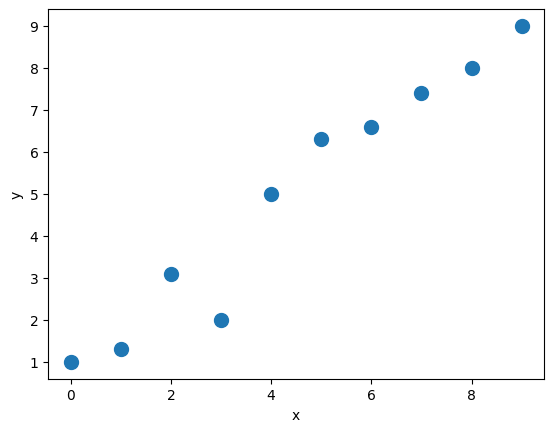

In [41]:
X_train = np.arange(10, dtype='float32').reshape((10, 1))
y_train = np.array([1.0, 1.3, 3.1, 2.0, 5.0,
                    6.3, 6.6, 7.4, 8.0,
                    9.0], dtype='float32')
plt.plot(X_train, y_train, 'o', markersize=10)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

Next, we will standardize the features (mean centering and dividing by the standard deviation) and create a PyTorch Dataset for the training set and a corresponding DataLoader:

In [42]:
from torch.utils.data import TensorDataset

X_train_norm = (X_train - np.mean(X_train)) / np.std(X_train)
X_train_norm = torch.from_numpy(X_train_norm)
y_train = torch.from_numpy(y_train).float()
train_ds = TensorDataset(X_train_norm, y_train)
batch_size = 1
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

Here, we set a batch size of 1 for the DataLoader.

Now, we can define our model for linear regression as $z = wx + b$. Here, we are going to use torch.nn module. It provides predefined layers for building complex NN models, but to start, we will learn how to define a model from scratch. Later, we will see how to use those predefined layers.

For this regression problem, we will define a linear regression model from scratch. We will define the parameters of our model, weight and bias, which correspond to the weight and the bias parameters, respectively. Finally, we will define the model() function to determine how this model uses the input data to generate its output:

In [43]:
torch.manual_seed(1)
weight = torch.randn(1)
weight.requires_grad_()
bias = torch.zeros(1, requires_grad=True)
def model(xb):
    return xb @ weight + bias

After defining the model, we can define the loss function that we want to minimize to find the optimal model weights. Here, we will choose the mean squared error (MSE) as our loss function:

In [44]:
def loss_fn(input, target):
    return (input - target).pow(2).mean()

Furthermore, to learn the weight parametersof the model, we will use stochastic gradient descent. In this subsection, we will implement this training via SGD procedure by ourselves, but in the next subsection, we will use the SGD method from the optimization package, torch.optim, to do the same thing.

To implement the stochastic gradient descent algorithm, we need to compute the gradients. Rather than manually computing the gradients, we will use PyTorch's torch.autograd.backward function. We will cover torch.autograd and its different classes and functions for implementing automatic differentiation.

Now, we can set the learning rate and train the model for 200 epochs. The code for training the model against the batched version of the dataset is as follows:

In [45]:
learning_rate = 0.001
num_epochs = 200
log_epochs = 10

for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
    with torch.no_grad():
        weight -= learning_rate * weight.grad
        bias -= learning_rate * bias.grad
        weight.grad.zero_()
        bias.grad.zero_()
    if epoch % log_epochs == 0:
        print(f'Epoch {epoch}  Loss {loss.item():.4f}')

Epoch 0  Loss 46.5720
Epoch 10  Loss 27.1502
Epoch 20  Loss 1.6446
Epoch 30  Loss 14.4571
Epoch 40  Loss 11.7827
Epoch 50  Loss 6.4122
Epoch 60  Loss 0.6339
Epoch 70  Loss 3.1562
Epoch 80  Loss 2.0100
Epoch 90  Loss 0.3107
Epoch 100  Loss 0.7625
Epoch 110  Loss 1.0024
Epoch 120  Loss 0.0232
Epoch 130  Loss 0.5138
Epoch 140  Loss 0.0741
Epoch 150  Loss 1.8712
Epoch 160  Loss 0.0007
Epoch 170  Loss 0.0850
Epoch 180  Loss 0.0634
Epoch 190  Loss 0.0012


Let's look at the trained model and plot it. For the test data, we will create a NumPy array of values evenly spaced between 0 and 9. Since we trained our model with standardized features, we will also apply the same standardization to the test data:

Final Parameters: 2.670930862426758 4.88258695602417


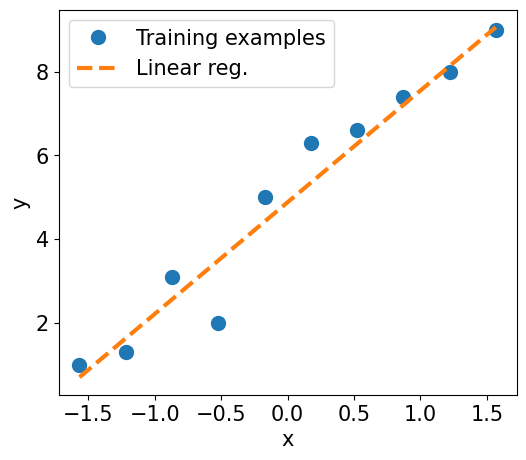

In [46]:
print('Final Parameters:', weight.item(), bias.item())
X_test = np.linspace(0, 9, num=100, dtype='float32').reshape(-1, 1)
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm)
y_pred = model(X_test_norm).detach().numpy()
fig = plt.figure(figsize=(13, 5))
ax = fig.add_subplot(1, 2, 1)
plt.plot(X_train_norm, y_train, 'o', markersize=10)
plt.plot(X_test_norm, y_pred, '--', lw=3)
plt.legend(['Training examples', 'Linear reg.'], fontsize=15)
ax.set_xlabel('x', size=15)
ax.set_ylabel('y', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.show()

### Model Training via the torch.nn and torch.optim Modules

In the previous example, we saw how to train a model by writing a custom loss function loss_fn() and applied stochastic gradient descent optimization. However, writing the loss function and gradient updates can be a repeatable task across different projects. The torch.nn module provides a set of loss functions, and torch.optim supports most commonly used optimization algorithms that can be called to update the parameters based on the computed gradients. To see how they work, let's create a new MSE loss function and a stochastic gradient descent optimizer:

In [47]:
import torch.nn as nn
loss_fn = nn.MSELoss(reduction='mean')
input_size = 1
output_size = 1
model = nn.Linear(input_size, output_size)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

Note that here we use the torch.nn.Linear class for the linear layer instead of manually defining it.

Now, we can simply call the step() method of the optimizer to train the model. We can pass a batched dataset (such as train_dl):

In [48]:
for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        # Generate predictions
        pred = model(x_batch)[:, 0]
        # Calculate loss
        loss = loss_fn(pred, y_batch)
        #Compute gradients
        loss.backward()
        # Update parameters using gradients
        optimizer.step()
        # Reset the gradients to zero
        optimizer.zero_grad()
    if epoch % log_epochs==0:
        print(f'Epoch {epoch}, Loss {loss.item():.4f}')

Epoch 0, Loss 24.6684
Epoch 10, Loss 29.1377
Epoch 20, Loss 20.9207
Epoch 30, Loss 0.1257
Epoch 40, Loss 12.4922
Epoch 50, Loss 1.7845
Epoch 60, Loss 7.6425
Epoch 70, Loss 2.5606
Epoch 80, Loss 0.0157
Epoch 90, Loss 0.7548
Epoch 100, Loss 0.8412
Epoch 110, Loss 0.4923
Epoch 120, Loss 0.0823
Epoch 130, Loss 0.0794
Epoch 140, Loss 0.0891
Epoch 150, Loss 0.0973
Epoch 160, Loss 0.1043
Epoch 170, Loss 0.1103
Epoch 180, Loss 0.0009
Epoch 190, Loss 0.0764


After the model is trained, visualize the results and make sure that they are similar to the results of the previous method. To obtain the weight and bias parameters, we can do the following:

In [49]:
print('Final Parameters:', model.weight.item(), model.bias.item())

Final Parameters: 2.6496422290802 4.87706995010376


### Building a Multilayer Perceptron for Classifying Flowers in the Iris Dataset

In the previous example, we saw how to build a model from scratch. We trained this model using stochastic gradient descent optimization. While we started our journey based on the simplest possible example, you can see that defining the model from scratch, even for such a simple case, is neither appealing nor good practice. PyTorch instead provides already defined layers through torch.nn that can be readily used as the building blocks of an NN model. In this section, we will learn how to use these layers to solve a classification task using the Iris flower dataset (identifying between three species of irises) and build a two-layer perceptron using the torch.nn module. First, let's get the data from sklearn.datasets:

In [50]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
iris = load_iris()
X = iris['data']
y = iris['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1./3, random_state=1)

Here, we randomly select 100 samples $(2/3)$ for training and 50 samples ($1/3$) for testing.

Next, we standardize the features (mean centering and dividing by the standard deviation) and create a PyTorch Dataset for the training set and a corresponding DataLoader:

In [51]:
X_train_norm = (X_train - np.mean(X_train)) / np.std(X_train)
X_train_norm = torch.from_numpy(X_train_norm).float()
y_train = torch.from_numpy(y_train)
train_ds = TensorDataset(X_train_norm, y_train)
torch.manual_seed(1)
batch_size = 2
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

Here, we set the batch size to 2 for the DataLoader.

Now, we are ready to use the torch.nn module to build a model efficiently. In particular, using the nn.Module class, we can stack a few layers and build an NN. For this problem, we are going to use the Linear layer, which is also known as a fully connected layer or dense layer, and can be best represented by $f(w \times x + b)$, where x represents a tensor containing input features, w and b are the weight matrix and the bias vector, and $f$ is the activation function.

Each layer in an NN receives its inputs from the preceding layer; therefore, its dimensionality is fixed. Typically, we need to concern ourselves with the dimensionality of the output only when we design an NN architecture. Here, we want to define a model, with two hidden layers. The first one receives an input of four features and projects them to 16 neurons. The second layer receives the output of the previous layer (which has a size of 16) and projects them to three output neurons, since we have three class labels. This can be done as follows:

In [52]:
class Model(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.layer1(x)
        x = nn.Sigmoid()(x)
        x = self.layer2(x)
        return x

input_size = X_train_norm.shape[1]
hidden_size = 16
output_size = 3
model = Model(input_size, hidden_size, output_size)

Here, we used the sigmoid activation function for the first layer and softmax activation for the last (output) layer. Softmax activation in the last layer is used to support multiclass classification since we have three class labels here (which is why we have three neurons in the output layer). We will discuss the different activation functions and their applications later in the chapter.

Next, we specify the loss function as cross-entropy loss and the optimizer as Adam:

In [53]:
learning_rate = 0.001
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

Now, we can train the model. We will specify the number of epochs to be 100. The code of training the flower classification model is as follows:

In [54]:
num_epochs = 100
loss_hist = [0] * num_epochs
accuracy_hist = [0] * num_epochs
for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        loss_hist[epoch] += loss.item() * y_batch.size(0)
        is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
        accuracy_hist[epoch] += is_correct.sum()
    loss_hist[epoch] /= len(train_dl.dataset)
    accuracy_hist[epoch] /= len(train_dl.dataset)

The loss_hist and accuracy_hist lists keep the training loss and the training accuracy after each epoch. We can use this to visualize the learning curves as follows:

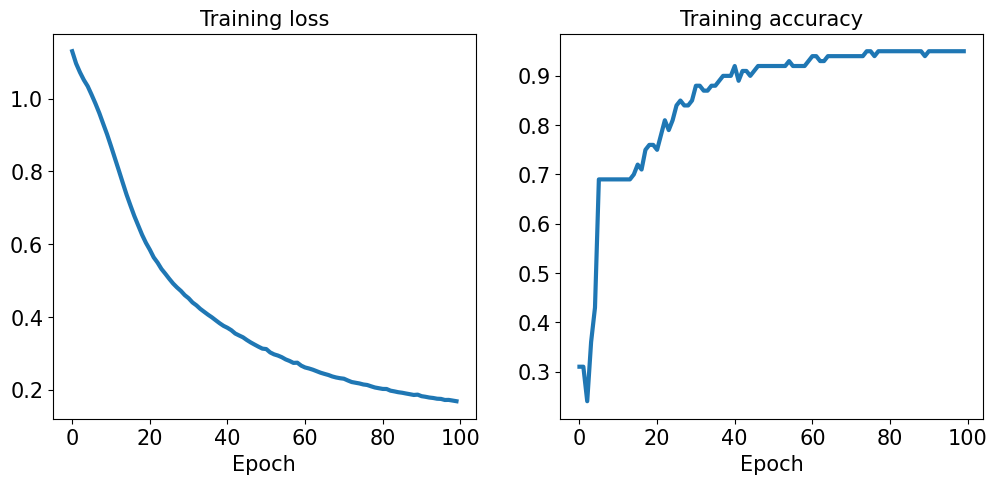

In [55]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1)
ax.plot(loss_hist, lw=3)
ax.set_title("Training loss", size=15)
ax.set_xlabel("Epoch", size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax = fig.add_subplot(1, 2, 2)
ax.plot(accuracy_hist, lw=3)
ax.set_title("Training accuracy", size=15)
ax.set_xlabel("Epoch", size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.show()

The learning curves (training loss and training accuracy) are as given above.

### Evaluating the Trained Model on the Test Dataset

We can now evaluate the classification accuracy of the trained model on the test dataset:

In [56]:
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm).float()
y_test = torch.from_numpy(y_test) 
pred_test = model(X_test_norm)
correct = (torch.argmax(pred_test, dim=1) == y_test).float()
accuracy = correct.mean()
print(f'Test Acc.: {accuracy:.4f}')

Test Acc.: 0.9800


Since we trained our model with standardized features, we also applied the same standardization to the test data. The classification accuracy is 0.98 (that is 98 percent).

### Saving and Reloading the Trained Model

Trained models can be saved on disk for future use. This can be done as follows:

In [57]:
path = 'iris_classifier.pt'
torch.save(model, path)

Calling save(model) will save both the model architecture and all the learned parameters. As a common convention, we can save models using a 'pt' or 'pth' file extension.

Now, let's reload the saved model. Since we have saved both the model architecture and the weights, we can easily rebuild and reload the parameters in just one line:

In [58]:
model_new = torch.load(path, weights_only = False)

Try to verify the model architecture by calling model_new.eval()

In [59]:
model_new.eval()

Model(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=3, bias=True)
)

Finally, let's evaluate this new model that is reloaded on the test dataset to verify that the results are the same as before:

In [60]:
pred_test = model_new(X_test_norm)
correct = (torch.argmax(pred_test, dim=1) == y_test).float()
accuracy = correct.mean()
print(f'Test Acc.: {accuracy:.4f}')

Test Acc.: 0.9800


If you want to save only the learned parameters, you can use save(model.state_dict()) as follows:

In [61]:
path = 'iris_classifier_state.pt'
torch.save(model.state_dict(), path)

To reload the saved parameters, we first need to construct the model as we did before, then feed the loaded parameters to the model:

In [62]:
model_new = Model(input_size, hidden_size, output_size)
model_new.load_state_dict(torch.load(path))

<All keys matched successfully>

### Logistic Function Recap

Let's take a model or a two-dimensional data point, x, and a model with the following weight coefficients assigned to the w vector (note that $w_0$ is the bias unit, which means $x_0 = 1$):

In [63]:
import numpy as np
X = np.array([1, 1.4, 2.5]) # first value must be 1
w = np.array([0.4, 0.3, 0.5])
def net_input(X, w):
    return np.dot(X, w)
def logistic(z):
    return 1.0 / (1.0 + np.exp(-z))
def logistic_activation(X, w):
    z = net_input(X, w)
    return logistic(z)
print(f'P(y=1|x) = {logistic_activation(X, w):.3f}')

P(y=1|x) = 0.888


If we calculate the net input (z) and use it to activate a logistic neuron with those particular feature values and weight coefficients, we get a value of 0.888, which we can interpret as an 88.8 percent probability that this particular sample, x, belongs to the positive class.

In the previous chapter, we used the one-hot encoding technique to represent multiclass ground truth labels and designed the output layer consisting of multiple logistic activation units. However, as will be demonstrated by the following code example, an output layer consisting of multiple logistic activation units does not produce meaningful, interpretable probability values:

In [64]:
# W : array with shape = (n_output_units, n_hidden_units+1)
#     note that the firsts column are the bias units
W = np.array([[1.1, 1.2, 0.8, 0.4],
              [0.2, 0.4, 1.0, 0.2],
              [0.6, 1.5, 1.2, 0.7]])

# A : data array with shape = (n_hidden_units + 1, n_samples)
#     note that the first column of this array must be 1

A = np.array([[1, 0.1, 0.4, 0.6]])
Z = np.dot(W, A[0])
y_probas = logistic(Z)
print('Net Input: \n', Z)
print('Output Units:\n', y_probas)

Net Input: 
 [1.78 0.76 1.65]
Output Units:
 [0.856 0.681 0.839]


As we can see in the output, the resulting values cannot be interpreted as probabilities for a three-class problem. The reason for this is that they do not sum to 1. However, this is, in fact, not a big concern if we use our model to predict only the class labels and not the class membership probabilities. One way to predict the class label from the output units obtained earlier is to use the maximum value:

In [65]:
y_class = np.argmax(Z, axis=0)
print('Predicted class label:', y_class)

Predicted class label: 0


In certain contexts, it can be useful to compute the meaningful class probabilities for multiclass predictions. In the next section, we will take a look at a generalization fo the logistic function, the softmax function, which can help us with this task.

### Estimating Class Probabilities in Multiclass Classification via the Softmax Function

To see softmax in action, let's code it up in Python:

In [66]:
def softmax(z):
    return np.exp(z) / np.sum(np.exp(z))

y_probas = softmax(Z)
print('Probabilities:\n', y_probas)

np.sum(y_probas)

Probabilities:
 [0.447 0.161 0.392]


np.float64(1.0)

As we can see, the predicted class probabilities now sum to 1, as we would expect. It is also notable that the predicted class label is the same as when we applied the argmax function to the logistic output.

It may help to think of the result of the softmax function as a normalized output that is useful for obtaining meaningful class-membership predictions in multiclass settings. Therefore, when we build a multiclass classification model in PyTorch, we can use the torch.softmax() function to estimate the probabilities of each class membership for an input batch of exmaples. To see how we can use the torch.softmax() activation function in PyTorch, we will convert Z to a tensor in the following code, with an additional dimension reserved for batch size:

In [67]:
torch.softmax(torch.from_numpy(Z), dim=0)


tensor([0.4467, 0.1611, 0.3922], dtype=torch.float64)

### Broadening the Output Spectrum Using a Hyperbolic Tangent

For a simple comparison of the logistic function and the hyperbolic tangent, let's plot the two sigmoidal functions:

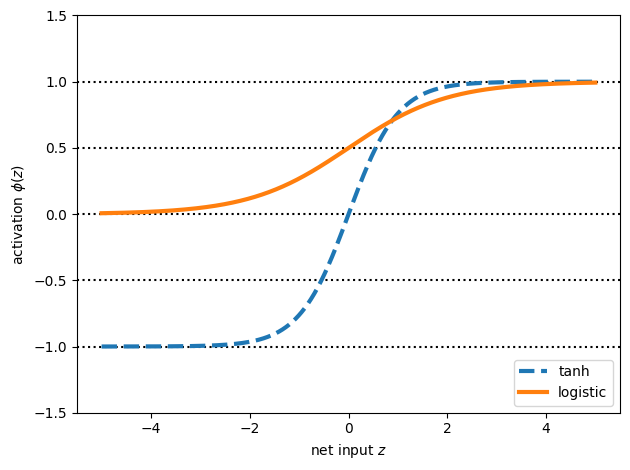

In [68]:
import matplotlib.pyplot as plt
def tanh(z):
    e_p = np.exp(z)
    e_m = np.exp(-z)
    return (e_p - e_m) / (e_p + e_m)

z = np.arange(-5, 5, 0.005)
log_act = logistic(z)
tanh_act = tanh(z)
plt.ylim([-1.5, 1.5])
plt.xlabel(r'net input $z$')
plt.ylabel(r'activation $\phi(z)$')
plt.axhline(1, color='black', linestyle=':')
plt.axhline(0.5, color='black', linestyle=':')
plt.axhline(0, color='black', linestyle=':')
plt.axhline(-0.5, color='black', linestyle=':')
plt.axhline(-1, color='black', linestyle=':')
plt.plot(z, tanh_act, label='tanh', linewidth=3, linestyle='--')
plt.plot(z, log_act, label='logistic', linewidth=3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

As we can see, the shapes of the two sigmoidal curves look very similar, however, the tanh function has double the output space of the logistic function. 

Now that we have implemented the logistic and tanh functions verbosely for the purpose of illustration, we can use NumPy's tanh function. Alternatively, when building an NN model, we can use the torch.tanh(x) in PyTorch to achieve the same results:

In [69]:
print(np.tanh(z))
print(torch.tanh(torch.from_numpy(z)))

[-1. -1. -1. ...  1.  1.  1.]
tensor([-0.9999, -0.9999, -0.9999,  ...,  0.9999,  0.9999,  0.9999],
       dtype=torch.float64)


In addition, the logistic function is available in SciPy's special module:

In [70]:
from scipy.special import expit
expit(z)

array([0.007, 0.007, 0.007, ..., 0.993, 0.993, 0.993], shape=(2000,))

Similarly, we can use the torch.sigmoid() function in PyTorch to do the same computation, as follows:

In [71]:
torch.sigmoid(torch.from_numpy(z))

tensor([0.0067, 0.0067, 0.0068,  ..., 0.9932, 0.9932, 0.9933],
       dtype=torch.float64)

### Rectified Linear Unit Activation

In PyTorch, we can apply the ReLU activation torch.relu() as follows:

In [72]:
torch.relu(torch.from_numpy(z))

tensor([0.0000, 0.0000, 0.0000,  ..., 4.9850, 4.9900, 4.9950],
       dtype=torch.float64)